In [1]:
!pip install librosa soundfile

In [2]:
#Mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/ml_project/data/ravdess"

In [4]:
import os
import numpy as np
import librosa
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

In [56]:
import random

def augment_audio(y, sr):
    # Add noise
    noise = np.random.randn(len(y))
    y = y + 0.005 * noise

    # Pitch shift (random)
    if random.random() > 0.5:
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=random.randint(-2,2))

    return y

In [57]:
##Create Mel Spectrogram Dataset
EMOTION_MAP = {
    '01': 0, '02': 1, '03': 2, '04': 3,
    '05': 4, '06': 5, '07': 6, '08': 7
}

def extract_mel_spectrogram(file_path, max_len=130, augment=False):
    y, sr = librosa.load(file_path, sr=16000)

    # Apply augmentation
    if augment and random.random() > 0.7:
        noise = np.random.randn(len(y))
        y = y + 0.005 * noise

        if random.random() > 0.5:
            y = librosa.effects.pitch_shift(y, sr=sr, n_steps=random.randint(-2,2))

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # GUARANTEED FIXED SHAPE
    if mel_db.shape[1] < max_len:
        pad_width = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]

    return mel_db

In [58]:
def load_data(data_path):
    X, y = [], []

    files = []
    for root, _, filenames in os.walk(data_path):
        for f in filenames:
            if f.endswith(".wav"):
                files.append(os.path.join(root, f))

    print("Total files:", len(files))

    for file in tqdm(files):
        try:
            mel = extract_mel_spectrogram(file, augment=True)

            label = file.split("/")[-1].split("-")[2]
            label = EMOTION_MAP[label]

            X.append(mel)
            y.append(label)

        except Exception as e:
            print("Error:", e)
            continue

    return np.array(X), np.array(y)

X, y = load_data(DATA_PATH)

print(X.shape)  # should be (1440, 128, 130)
print(set([x.shape for x in X]))

Total files: 1440


100%|██████████| 1440/1440 [00:40<00:00, 35.64it/s]


(1440, 128, 130)
{(128, 130)}


In [59]:
# Normalize
X = (X - X.mean()) / X.std()

# Add channel dimension
X = X[..., np.newaxis]

print(X.shape)  # (1440, 128, 130, 1)

(1440, 128, 130, 1)


In [60]:
##saving X,y as the loading function takes much time in collab ..(normalized X and y)

np.save("X_mel.npy", X)
np.save("y.npy", y)

##ALSO saving mean and std
mean = X.mean()
std = X.std()

np.save("norm_mean.npy", mean)
np.save("norm_std.npy", std)

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [62]:


model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,130,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3 (reduced from 128 → 64)
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(8, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 29, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,992 (12.61 MB)

 Trainable params: 3,305,544 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [63]:
##Train Model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.1813 - loss: 4.3981 - val_accuracy: 0.1732 - val_loss: 2.2545
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2541 - loss: 1.9777 - val_accuracy: 0.1385 - val_loss: 4.3952
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2584 - loss: 1.9604 - val_accuracy: 0.1255 - val_loss: 10.0553
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2704 - loss: 1.8937 - val_accuracy: 0.1255 - val_loss: 9.9216
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3116 - loss: 1.8345 - val_accuracy: 0.1255 - val_loss: 12.6119
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3181 - loss: 1.8225 - val_accuracy: 0.1255 - val_loss: 12.2800
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2410 - loss: 1.8901 - val_accuracy: 0.1472 - val_loss: 8.4988
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2942 - loss: 1.8316 - val_accuracy: 0.216

In [33]:
##Below code with some improvements i.e with callback

In [64]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt


In [65]:
##Callbacks setup
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [66]:
##train_with_callbacks
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5560 - loss: 1.0384

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5831 - loss: 1.0338 - val_accuracy: 0.4459 - val_loss: 1.4748 - learning_rate: 0.0010
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5874 - loss: 1.0230 - val_accuracy: 0.4372 - val_loss: 1.8030 - learning_rate: 0.0010
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5907 - loss: 1.0048 - val_accuracy: 0.4069 - val_loss: 1.5172 - learning_rate: 0.0010
Epoch 4/30
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5803 - loss: 0.9626

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5733 - loss: 1.0015 - val_accuracy: 0.4589 - val_loss: 1.4609 - learning_rate: 0.0010
Epoch 5/30
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6135 - loss: 0.9155

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6080 - loss: 0.9248 - val_accuracy: 0.4762 - val_loss: 1.4451 - learning_rate: 0.0010
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5711 - loss: 1.0089 - val_accuracy: 0.4545 - val_loss: 1.7944 - learning_rate: 0.0010
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5668 - loss: 1.0524 - val_accuracy: 0.4502 - val_loss: 1.8303 - learning_rate: 0.0010
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6004 - loss: 1.0004 - val_accuracy: 0.3853 - val_loss: 1.8859 - learning_rate: 0.0010
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5917 - loss: 0.9467 - val_accuracy: 0.4502 - val_loss: 1.7198 - learning_rate: 5.0000e-04
Epoch 10/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6026 - loss: 0.8885 - val_accuracy: 0.4762 - val_loss: 1.5916 - learning_rate: 5.0000e-04


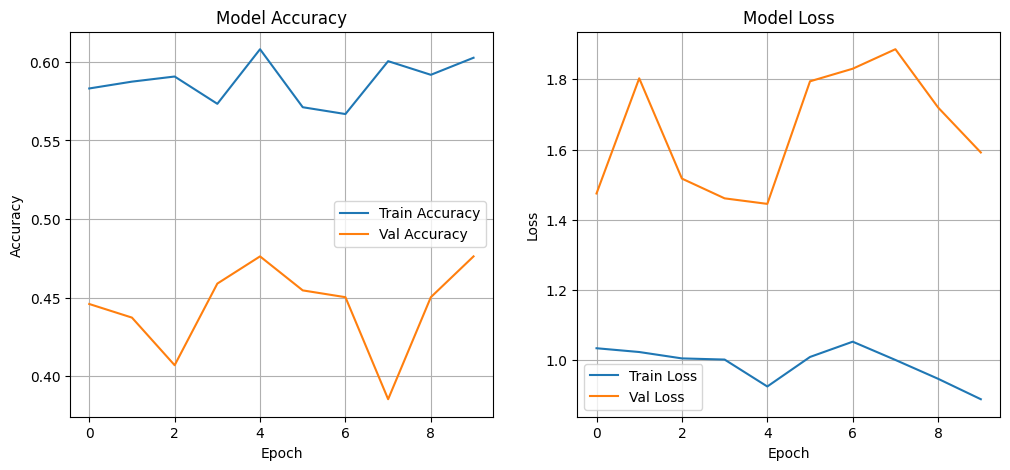

In [67]:

# Accuracy plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


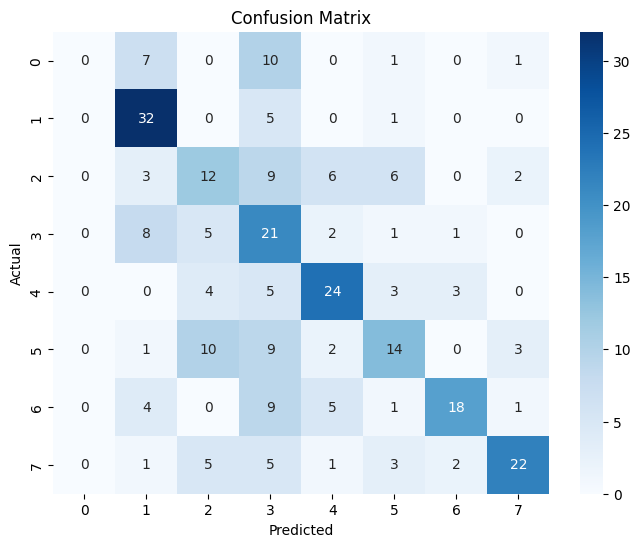

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [69]:
model.save("final_model.h5")

np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

In [70]:
##Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4965 - loss: 1.4948
Test Accuracy: 0.4965277910232544
